In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [5]:
df = pd.read_csv("/content/data/raw/fifa21_raw_data.csv", engine='python', on_bad_lines='skip')

In [22]:
def convert_height(h):
    if isinstance(h, str) and "'" in h:
        ft, inch = h.split("'")
        inch = inch.replace('"', '')
        return int(ft) * 30.48 + int(inch) * 2.54
    return pd.to_numeric(h, errors="coerce")
    df["Height"] = df["Height"].apply(convert_height)


In [9]:
def convert_weight(w):
    # Format example: 150lbs
    if isinstance(w, str) and "lbs" in w:
        return int(w.replace("lbs", "").strip()) * 0.453592
    return pd.to_numeric(w, errors="coerce")
df["Weight"] = df["Weight"].apply(convert_weight)

In [24]:
df[["Name", "Height", "Weight"]].head()


,Name,Height,Weight
0,L. Messi,"5'7""",72.121128
1,Cristiano Ronaldo,"6'2""",83.007336
2,J. Oblak,"6'2""",87.089664
3,K. De Bruyne,"5'11""",69.853168
4,Neymar Jr,"5'9""",68.038800


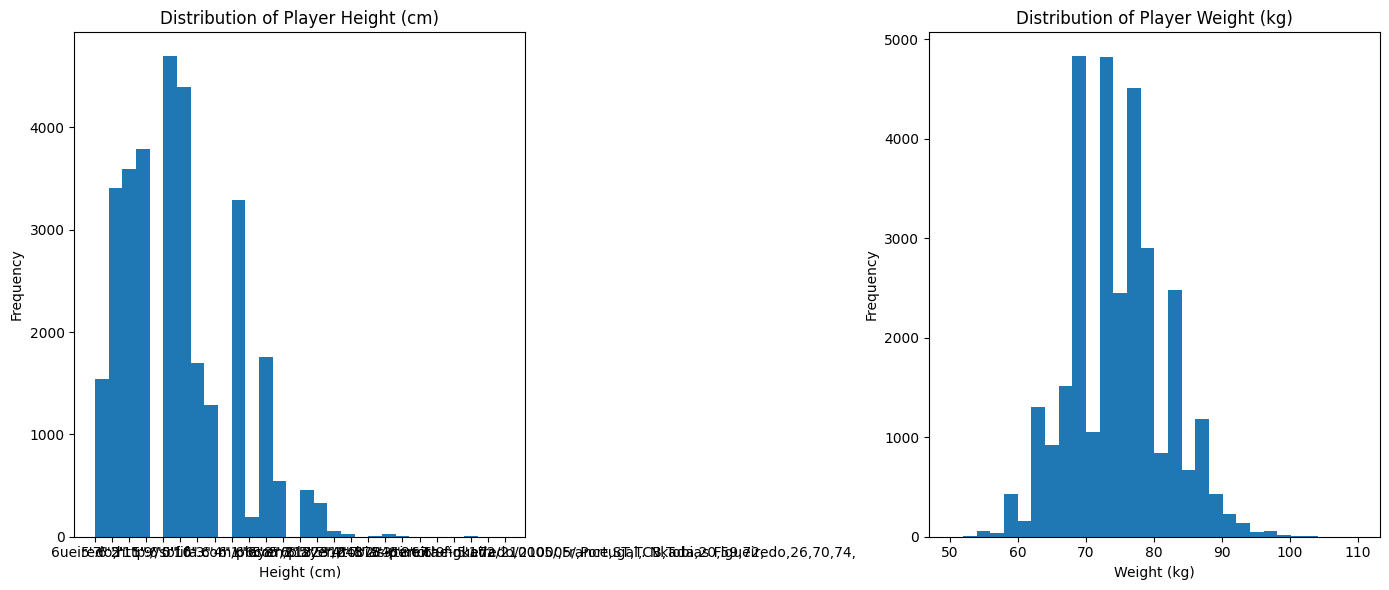

In [26]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.hist(df["Height"].dropna(), bins=30)
plt.title("Distribution of Player Height (cm)")
plt.xlabel("Height (cm)")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(df["Weight"].dropna(), bins=30)
plt.title("Distribution of Player Weight (kg)")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [15]:
df["Joined_year"] = pd.to_datetime(df["Joined"], errors="coerce").dt.year
df["Years_at_club"] = 2025 - df["Joined_year"]

players_10yrs = df[df["Years_at_club"] >= 10][["Name", "Years_at_club"]]

print("Players who stayed at a club for 10+ years:")
display(players_10yrs.head())

Players who stayed at a club for 10+ years:


,Name,Years_at_club
0,L. Messi,21.0
2,J. Oblak,11.0
3,K. De Bruyne,10.0
5,R. Lewandowski,11.0
11,M. ter Stegen,11.0


In [38]:
def money_to_float(x):
    if isinstance(x, str):
        x = x.replace("€", "").replace(",", "").strip()
        if "M" in x:
            return float(x.replace("M", "")) * 1_000_000
        if "K" in x:
            return float(x.replace("K", "")) * 1_000
        return pd.to_numeric(x, errors="coerce")
    return pd.to_numeric(x, errors="coerce")

for col in ["Value", "Wage", "Release Clause"]:
    df[col + "_num"] = df[col].apply(money_to_float)

from IPython.display import display
display(df)

,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,...,PAC,SHO,PAS,DRI,DEF,PHY,Hits,Value_num,Wage_num,Release Clause_num
0,https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,...,85.0,92.0,91.0,95.0,38.0,65.0,\n372,67500000.0,560000.0,138400000.0
1,https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,...,89.0,93.0,81.0,89.0,35.0,77.0,\n344,46000000.0,220000.0,75900000.0
2,https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,...,87.0,92.0,78.0,90.0,52.0,90.0,\n86,75000000.0,125000.0,159400000.0
3,https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,\n\n\n\nManchester City\n2015 ~ 2023\n\n,...,76.0,86.0,93.0,88.0,64.0,78.0,\n163,87000000.0,370000.0,161000000.0
4,https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,...,91.0,85.0,86.0,94.0,36.0,59.0,\n273,90000000.0,270000.0,166500000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31112,https://cdn.sofifa.com/players/257/710/21_60.png,Mengxuan Zhang,http://sofifa.com/player/257710/mengxuan-zhang...,China PR,CB,Zhang Mengxuan,21,47,52,\n\n\n\nChongqing Dangdai Lifan FC SWM Team\n2...,...,58.0,23.0,26.0,27.0,50.0,48.0,\n2,35000.0,1000.0,57000.0
31113,https://cdn.sofifa.com/players/258/736/21_60.png,Vani Da Silva,http://sofifa.com/player/258736/vani-da-silva/...,England,ST,V. Da Silva,17,47,67,\n\n\n\nOldham Athletic\n2020 ~ 2021\n\n,...,70.0,46.0,40.0,53.0,16.0,40.0,\n3,60000.0,500.0,165000.0
31114,https://cdn.sofifa.com/players/247/223/21_60.png,Ao Xia,http://sofifa.com/player/247223/ao-xia/210005/,China PR,CB,Xia Ao,21,47,55,\n\n\n\nWuhan Zall\n2018 ~ 2022\n\n,...,64.0,28.0,26.0,38.0,48.0,51.0,\n3,40000.0,1000.0,70000.0
31115,https://cdn.sofifa.com/players/258/760/21_60.png,Ben Hough,http://sofifa.com/player/258760/ben-hough/210005/,England,CM,B. Hough,17,47,67,\n\n\n\nOldham Athletic\n2020 ~ 2021\n\n,...,64.0,40.0,48.0,49.0,35.0,45.0,\n5,60000.0,500.0,165000.0


In [60]:
import pandas as pd
from IPython.display import display

df = pd.read_csv("/content/data/raw/fifa21_raw_data.csv", engine='python', on_bad_lines='skip')

star_cols = [col for col in df.columns if df[col].astype(str).str.contains("★").any()]

display(df[star_cols])

,Name,Age,↓OVA,Team & Contract,ID,W/F,SM,IR
0,L. Messi,33,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,158023,4 ★,4★,5 ★
1,Cristiano Ronaldo,35,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,20801,4 ★,5★,5 ★
2,J. Oblak,27,91,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,200389,3 ★,1★,3 ★
3,K. De Bruyne,29,91,\n\n\n\nManchester City\n2015 ~ 2023\n\n,192985,5 ★,4★,4 ★
4,Neymar Jr,28,91,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,190871,5 ★,5★,5 ★
...,...,...,...,...,...,...,...,...
31112,Zhang Mengxuan,21,47,\n\n\n\nChongqing Dangdai Lifan FC SWM Team\n2...,257710,2 ★,2★,1 ★
31113,V. Da Silva,17,47,\n\n\n\nOldham Athletic\n2020 ~ 2021\n\n,258736,2 ★,2★,1 ★
31114,Xia Ao,21,47,\n\n\n\nWuhan Zall\n2018 ~ 2022\n\n,247223,2 ★,2★,1 ★
31115,B. Hough,17,47,\n\n\n\nOldham Athletic\n2020 ~ 2021\n\n,258760,2 ★,2★,1 ★


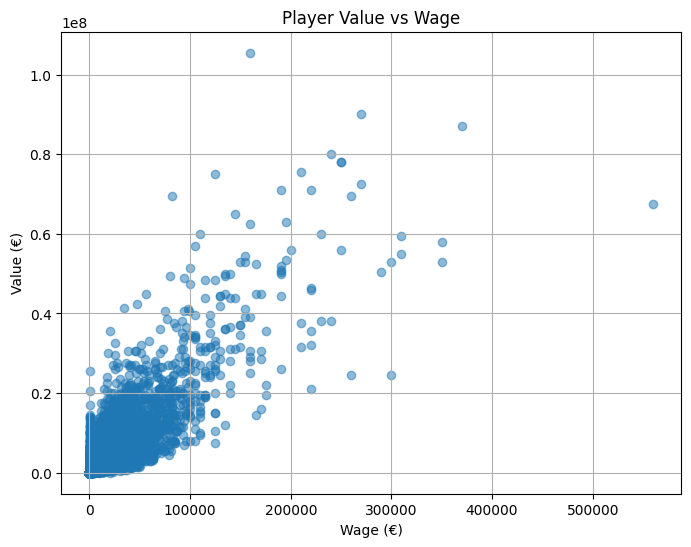

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(df["Wage_num"], df["Value_num"], alpha=0.5)
plt.xlabel("Wage (€)")
plt.ylabel("Value (€)")
plt.title("Player Value vs Wage")
plt.grid(True)
plt.show()

In [19]:
df.head()

,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,...,Wage_num,Release Clause_num,Name_num,Age_num,↓OVA_num,Team & Contract_num,ID_num,W/F_num,SM_num,IR_num
0,https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,FC Barcelona 2004 ~ 2021,...,560000.0,138400000.0,NaN,33.0,93.0,NaN,158023.0,4.0,4.0,5.0
1,https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,Juventus 2018 ~ 2022,...,220000.0,75900000.0,NaN,35.0,92.0,NaN,20801.0,4.0,5.0,5.0
2,https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,Atlético Madrid 2014 ~ 2023,...,125000.0,159400000.0,NaN,27.0,91.0,NaN,200389.0,3.0,1.0,3.0
3,https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,Manchester City 2015 ~ 2023,...,370000.0,161000000.0,NaN,29.0,91.0,NaN,192985.0,5.0,4.0,4.0
4,https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,Paris Saint-Germain 2017 ~ 2022,...,270000.0,166500000.0,NaN,28.0,91.0,NaN,190871.0,5.0,5.0,5.0
